<div style="text-align:left;">
    <span style="
        display:inline-block;
        background-color:#4169E1;
        color:white;
        padding:10px 20px;
        border-radius:8px;
        font-size:45px;
        font-weight:bold;
    ">
        Multi-layer Perceptron Model
    </span>
</div>

**Author:** Sarra Chouk 

**Student ID:** 60300372

**Project:** EHR Mortality Risk Prediction  

**Dataset:** MIMIC-IV

**Date:** April 4, 2026  

---

### **Objective**
To trains a deep multi-layer perceptron.

### **Model Setup and Library Imports**

In [9]:
from __future__ import annotations

import copy
import os
import tempfile
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib-cache"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore", category=UserWarning)

### **Path Resolution**

In [10]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "processed").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/processed.")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())

# Use canonical imputed split artifacts
SPLITS_DIR = PROJECT_ROOT / "data" / "processed" / "splits_imputed"

RANDOM_STATE = 42
VAL_SHARE_OF_TRAIN = 0.10

HIDDEN_LAYER_SIZES = (128, 64, 32)
LEARNING_RATE_INIT = 5e-4
BATCH_SIZE = 4096
ALPHA = 1e-4
MAX_EPOCHS = 25
PATIENCE = 5
MIN_DELTA = 1e-4

np.random.seed(RANDOM_STATE)

print(f"Project root: {PROJECT_ROOT}")
print(f"Splits dir: {SPLITS_DIR}")

Project root: /Users/sarrachouk/Desktop/ehr-mortality-prediction
Splits dir: /Users/sarrachouk/Desktop/ehr-mortality-prediction/data/processed/splits_imputed


### **Load Split Artifacts**

In [ ]:
required_files = [
    "X_train.csv",
    "y_train.csv",
    "X_test.csv",
    "y_test.csv",
    "X_deployment.csv",
    "y_deployment.csv",
]

missing_files = [fname for fname in required_files if not (SPLITS_DIR / fname).exists()]
if missing_files:
    raise FileNotFoundError(f"Missing canonical split files: {missing_files}")

print("All canonical split files found.")

### **Dataset Overview**

In [12]:
X_train_full = pd.read_csv(SPLITS_DIR / "X_train.csv")
y_train_full = pd.read_csv(SPLITS_DIR / "y_train.csv").squeeze("columns").astype("int8")

X_test = pd.read_csv(SPLITS_DIR / "X_test.csv")
y_test = pd.read_csv(SPLITS_DIR / "y_test.csv").squeeze("columns").astype("int8")

X_deployment = pd.read_csv(SPLITS_DIR / "X_deployment.csv")
y_deployment = pd.read_csv(SPLITS_DIR / "y_deployment.csv").squeeze("columns").astype("int8")

print("Loaded canonical split artifacts.")
print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("X_deployment:", X_deployment.shape)
print("y_deployment:", y_deployment.shape)

Loaded canonical split artifacts.
X_train_full: (380461, 49)
y_train_full: (380461,)
X_test: (83356, 49)
y_test: (83356,)
X_deployment: (82211, 49)
y_deployment: (82211,)


In [13]:
dataset_summary = pd.DataFrame(
    [
        {
            "split": "train_full",
            "rows": len(X_train_full),
            "positive_rate": y_train_full.mean(),
        },
        {
            "split": "test",
            "rows": len(X_test),
            "positive_rate": y_test.mean(),
        },
        {
            "split": "deployment",
            "rows": len(X_deployment),
            "positive_rate": y_deployment.mean(),
        },
    ]
).set_index("split").round(4)

display(dataset_summary)

,rows,positive_rate
split,,
train_full,380461,0.0217
test,83356,0.0212
deployment,82211,0.0215


### **Validation Split Creation**

In [14]:
X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_full,
    y_train_full,
    test_size=VAL_SHARE_OF_TRAIN,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

print("Derived validation split from canonical training data.")
print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)

Derived validation split from canonical training data.
X_train: (342414, 49)
X_validation: (38047, 49)


### **Sanity Checks**

In [15]:
for split_name, X_split in {
    "train": X_train,
    "validation": X_validation,
    "test": X_test,
    "deployment": X_deployment,
}.items():
    if X_split.isna().sum().sum() > 0:
        raise ValueError(f"NaNs found in {split_name} features. Imputed split expected to be complete.")

feature_cols = X_train.columns.tolist()

print(f"Using {len(feature_cols)} model-ready features.")
print("All splits are fully numeric and already imputed.")

Using 49 model-ready features.
All splits are fully numeric and already imputed.


### **Feature Scaling**

In [16]:
scaler = StandardScaler()

X = {}
y = {}

X["train"] = scaler.fit_transform(X_train).astype("float32")
y["train"] = y_train.to_numpy(dtype="int8")

X["validation"] = scaler.transform(X_validation).astype("float32")
y["validation"] = y_validation.to_numpy(dtype="int8")

X["test"] = scaler.transform(X_test).astype("float32")
y["test"] = y_test.to_numpy(dtype="int8")

X["deployment"] = scaler.transform(X_deployment).astype("float32")
y["deployment"] = y_deployment.to_numpy(dtype="int8")

shape_summary = pd.Series({split_name: values.shape for split_name, values in X.items()}, name="shape")
display(shape_summary)

train         (342414, 49)
validation     (38047, 49)
test           (83356, 49)
deployment     (82211, 49)
Name: shape, dtype: object

### **Metrics**

In [18]:
def select_best_f1_threshold(y_true: np.ndarray, y_proba: np.ndarray) -> float:
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    if len(thresholds) == 0:
        return 0.5
    f1_scores = 2 * precision[1:] * recall[1:] / np.clip(precision[1:] + recall[1:], 1e-12, None)
    best_idx = int(np.nanargmax(f1_scores))
    return float(thresholds[best_idx])


def evaluate_ranking_metrics(y_true: np.ndarray, y_proba: np.ndarray) -> dict[str, float]:
    return {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba),
        "log_loss": log_loss(y_true, y_proba, labels=[0, 1]),
    }


def evaluate_classification_metrics(
    y_true: np.ndarray,
    y_proba: np.ndarray,
    threshold: float,
) -> dict[str, float]:
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "predicted_positive_rate": y_pred.mean(),
    }

### **Model Definition and Training**

In [19]:
def train_mlp_model(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
) -> tuple[MLPClassifier, pd.DataFrame]:
    model = MLPClassifier(
        hidden_layer_sizes=HIDDEN_LAYER_SIZES,
        activation="relu",
        solver="adam",
        alpha=ALPHA,
        batch_size=BATCH_SIZE,
        learning_rate_init=LEARNING_RATE_INIT,
        max_iter=1,
        shuffle=True,
        random_state=RANDOM_STATE,
        warm_start=True,
    )

    sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
    classes = np.array([0, 1], dtype=np.int64)

    history = []
    best_model = None
    best_val_pr_auc = -np.inf
    epochs_without_improvement = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.partial_fit(X_train, y_train, classes=classes, sample_weight=sample_weight)

        val_proba = model.predict_proba(X_val)[:, 1]
        val_pr_auc = average_precision_score(y_val, val_proba)
        val_roc_auc = roc_auc_score(y_val, val_proba)

        history.append(
            {
                "epoch": epoch,
                "train_loss": model.loss_,
                "val_pr_auc": val_pr_auc,
                "val_roc_auc": val_roc_auc,
            }
        )

        print(
            f"Epoch {epoch:02d} | train_loss={model.loss_:.5f} | "
            f"val_pr_auc={val_pr_auc:.5f} | val_roc_auc={val_roc_auc:.5f}"
        )

        if val_pr_auc > best_val_pr_auc + MIN_DELTA:
            best_val_pr_auc = val_pr_auc
            best_model = copy.deepcopy(model)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                print(f"Early stopping triggered after epoch {epoch}.")
                break

    history_df = pd.DataFrame(history)
    return (best_model or model), history_df

In [20]:
def plot_training_history(history_df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o")
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    axes[1].plot(history_df["epoch"], history_df["val_pr_auc"], marker="o", label="Validation PR-AUC")
    axes[1].plot(history_df["epoch"], history_df["val_roc_auc"], marker="o", label="Validation ROC-AUC")
    axes[1].set_title("Validation Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_split_curves(y_true: np.ndarray, y_proba: np.ndarray, split_name: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    PrecisionRecallDisplay.from_predictions(y_true, y_proba, ax=axes[0])
    axes[0].set_title(f"{split_name} Precision-Recall Curve")

    RocCurveDisplay.from_predictions(y_true, y_proba, ax=axes[1])
    axes[1].set_title(f"{split_name} ROC Curve")

    plt.tight_layout()
    plt.show()


def plot_confusion(y_true: np.ndarray, y_proba: np.ndarray, threshold: float, split_name: str) -> None:
    y_pred = (y_proba >= threshold).astype(int)
    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, colorbar=False)
    ax.set_title(f"{split_name} Confusion Matrix @ threshold={threshold:.3f}")
    plt.tight_layout()
    plt.show()

Epoch 01 | train_loss=0.56711 | val_pr_auc=0.12530 | val_roc_auc=0.83861
Epoch 02 | train_loss=0.48860 | val_pr_auc=0.13360 | val_roc_auc=0.85092
Epoch 03 | train_loss=0.47518 | val_pr_auc=0.13656 | val_roc_auc=0.85385
Epoch 04 | train_loss=0.46833 | val_pr_auc=0.13867 | val_roc_auc=0.85557
Epoch 05 | train_loss=0.46339 | val_pr_auc=0.13999 | val_roc_auc=0.85646
Epoch 06 | train_loss=0.45930 | val_pr_auc=0.14126 | val_roc_auc=0.85703
Epoch 07 | train_loss=0.45578 | val_pr_auc=0.14378 | val_roc_auc=0.85750
Epoch 08 | train_loss=0.45255 | val_pr_auc=0.14528 | val_roc_auc=0.85773
Epoch 09 | train_loss=0.44958 | val_pr_auc=0.14636 | val_roc_auc=0.85802
Epoch 10 | train_loss=0.44671 | val_pr_auc=0.14690 | val_roc_auc=0.85839
Epoch 11 | train_loss=0.44371 | val_pr_auc=0.14722 | val_roc_auc=0.85845
Epoch 12 | train_loss=0.44094 | val_pr_auc=0.14731 | val_roc_auc=0.85862
Epoch 13 | train_loss=0.43807 | val_pr_auc=0.14753 | val_roc_auc=0.85849
Epoch 14 | train_loss=0.43527 | val_pr_auc=0.14748 

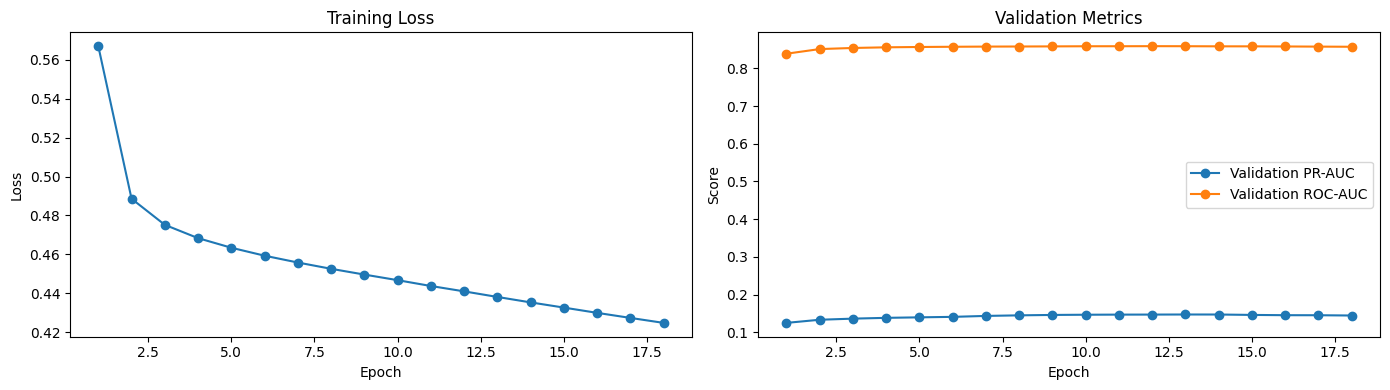

,epoch,train_loss,val_pr_auc,val_roc_auc
0,1,0.5671,0.1253,0.8386
1,2,0.4886,0.1336,0.8509
2,3,0.4752,0.1366,0.8539
3,4,0.4683,0.1387,0.8556
4,5,0.4634,0.1400,0.8565
5,6,0.4593,0.1413,0.8570
6,7,0.4558,0.1438,0.8575
7,8,0.4526,0.1453,0.8577
8,9,0.4496,0.1464,0.8580
9,10,0.4467,0.1469,0.8584


In [21]:
model, history_df = train_mlp_model(
    X_train=X["train"],
    y_train=y["train"],
    X_val=X["validation"],
    y_val=y["validation"],
)

plot_training_history(history_df)
display(history_df.round(4))

### **Probability Predictions**

In [22]:
probabilities = {
    split_name: model.predict_proba(X[split_name])[:, 1]
    for split_name in ["validation", "test", "deployment"]
}

best_threshold = select_best_f1_threshold(y["validation"], probabilities["validation"])
print(f"Best validation threshold by F1: {best_threshold:.4f}")

Best validation threshold by F1: 0.8865


### **Threshold Selection**

In [23]:
ranking_results = []
threshold_results = []

for split_name, split_proba in probabilities.items():
    ranking_results.append(
        {
            "split": split_name,
            **evaluate_ranking_metrics(y[split_name], split_proba),
        }
    )

    for strategy_name, threshold in {
        "default_0.50": 0.50,
        "validation_best_f1": best_threshold,
    }.items():
        threshold_results.append(
            {
                "split": split_name,
                "threshold_strategy": strategy_name,
                "threshold": threshold,
                **evaluate_classification_metrics(y[split_name], split_proba, threshold),
            }
        )

ranking_df = pd.DataFrame(ranking_results).set_index("split").round(4)
threshold_df = (
    pd.DataFrame(threshold_results)
    .sort_values(["threshold_strategy", "split"])
    .reset_index(drop=True)
    .round(4)
)

display(ranking_df)
display(threshold_df)

,roc_auc,pr_auc,brier_score,log_loss
split,,,,
validation,0.8585,0.1475,0.1718,0.4946
test,0.8528,0.1352,0.1727,0.4969
deployment,0.8550,0.1435,0.1702,0.4901


,split,threshold_strategy,threshold,accuracy,precision,recall,f1,predicted_positive_rate
0,deployment,default_0.50,0.5000,0.7287,0.0624,0.8272,0.1161,0.2854
1,test,default_0.50,0.5000,0.7249,0.0604,0.8220,0.1126,0.2888
2,validation,default_0.50,0.5000,0.7267,0.0629,0.8341,0.1170,0.2878
3,deployment,validation_best_f1,0.8865,0.9655,0.1944,0.1914,0.1929,0.0212
4,test,validation_best_f1,0.8865,0.9649,0.1972,0.2124,0.2045,0.0229
5,validation,validation_best_f1,0.8865,0.9655,0.2102,0.2143,0.2122,0.0221


### **Model Evaluation Plots**

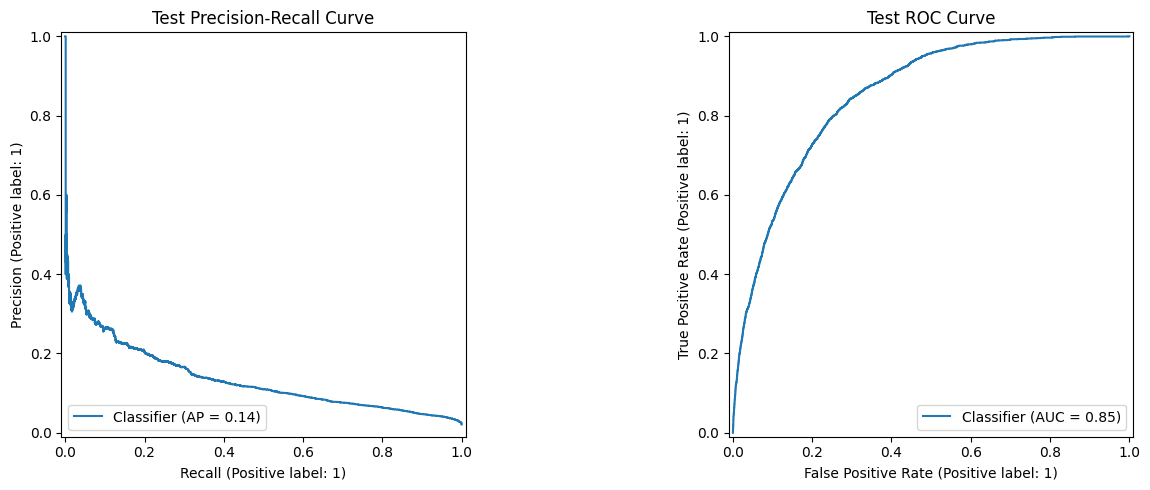

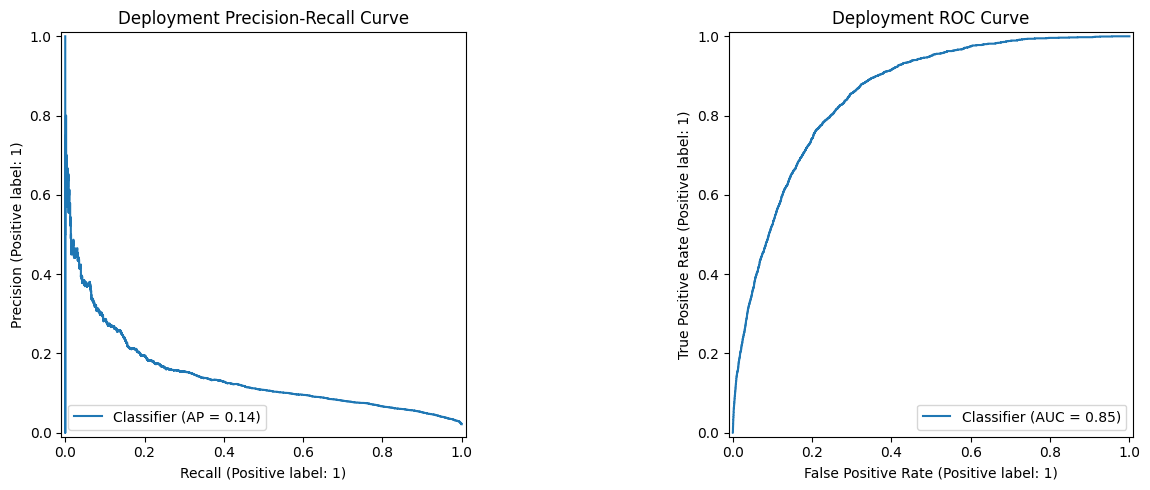

In [24]:
for split_name in ["test", "deployment"]:
    plot_split_curves(
        y_true=y[split_name],
        y_proba=probabilities[split_name],
        split_name=split_name.capitalize(),
    )

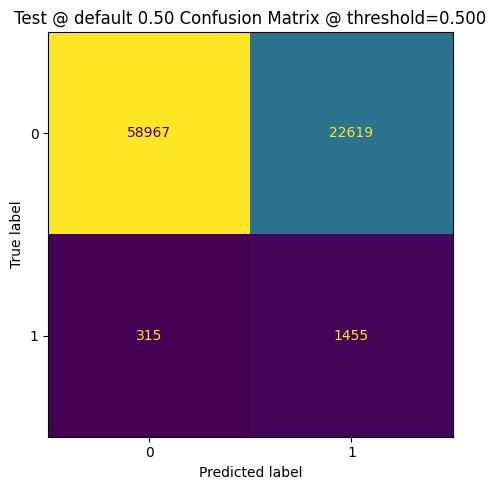

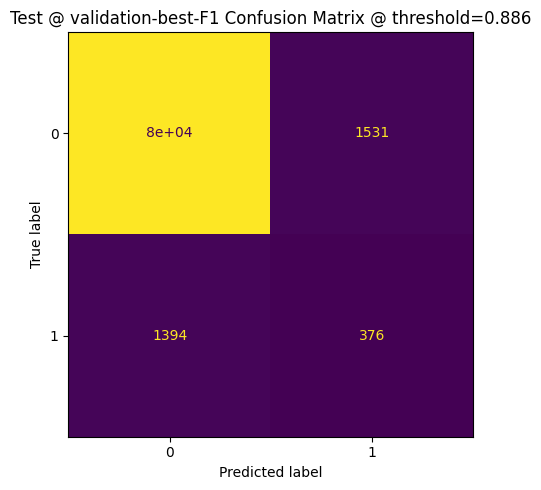

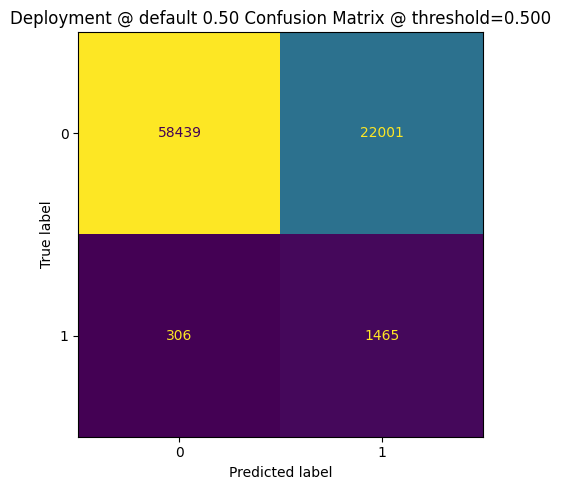

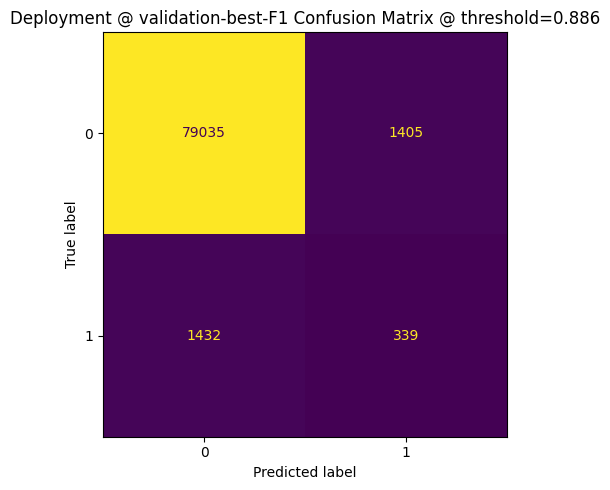

In [25]:
for split_name in ["test", "deployment"]:
    plot_confusion(
        y_true=y[split_name],
        y_proba=probabilities[split_name],
        threshold=0.50,
        split_name=f"{split_name.capitalize()} @ default 0.50",
    )

    plot_confusion(
        y_true=y[split_name],
        y_proba=probabilities[split_name],
        threshold=best_threshold,
        split_name=f"{split_name.capitalize()} @ validation-best-F1",
    )

In [27]:
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "mlp_evaluation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
ranking_df.to_csv(OUTPUT_DIR / "ranking_metrics.csv")
threshold_df.to_csv(OUTPUT_DIR / "threshold_metrics.csv", index=False)

print("Saved evaluation artifacts to:", OUTPUT_DIR)

Saved evaluation artifacts to: /Users/sarrachouk/Desktop/ehr-mortality-prediction/artifacts/mlp_evaluation
